In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape

(2240, 22)

In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [6]:
#DATA PREPROCESSING
#1.Handle missing values
df["Income"]=df["Income"].fillna(df["Income"].median())

In [7]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [8]:
#2.Feature engineering 
#age 
df["Age"]=2026-df["Year_Birth"]

In [9]:
#Customer Joining Date
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date=df["Dt_Customer"].max()
df["Customer_Tenure_Days"]=(reference_date-df["Dt_Customer"]).dt.days

In [10]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [11]:
#spending
df["Total_Spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]
#children
df["Total_children"]=df["Kidhome"]+df["Teenhome"]

In [12]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [13]:
#EDUCATION
df["Education"].value_counts()

#ug,graduate,pg
df["Education"]=df["Education"].replace({
    "Basic":"Undergraduate",
    "2n Cycle":"Undergraduate",
    "Master":"Postgraduate",
    "Graduation":"Graduate",
    "PhD":"Postgraduate"})

In [14]:
#Marital status
df["Living_With"]=df["Marital_Status"].replace({
    "Married":"Partner",
    "Together":"Partner",
    "Divorced":"Alone",
    "Single":"Alone",
    "YOLO":"Alone",
    "Widow":"Alone"})

df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       794
Absurd        2
Name: count, dtype: int64

In [15]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [16]:
#drop columns
cols=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

cols_to_drop=cols+spending_cols
df_cleaned=df.drop(columns=cols_to_drop)


In [17]:
df.shape

(2240, 27)

In [18]:
df_cleaned.shape

(2240, 15)

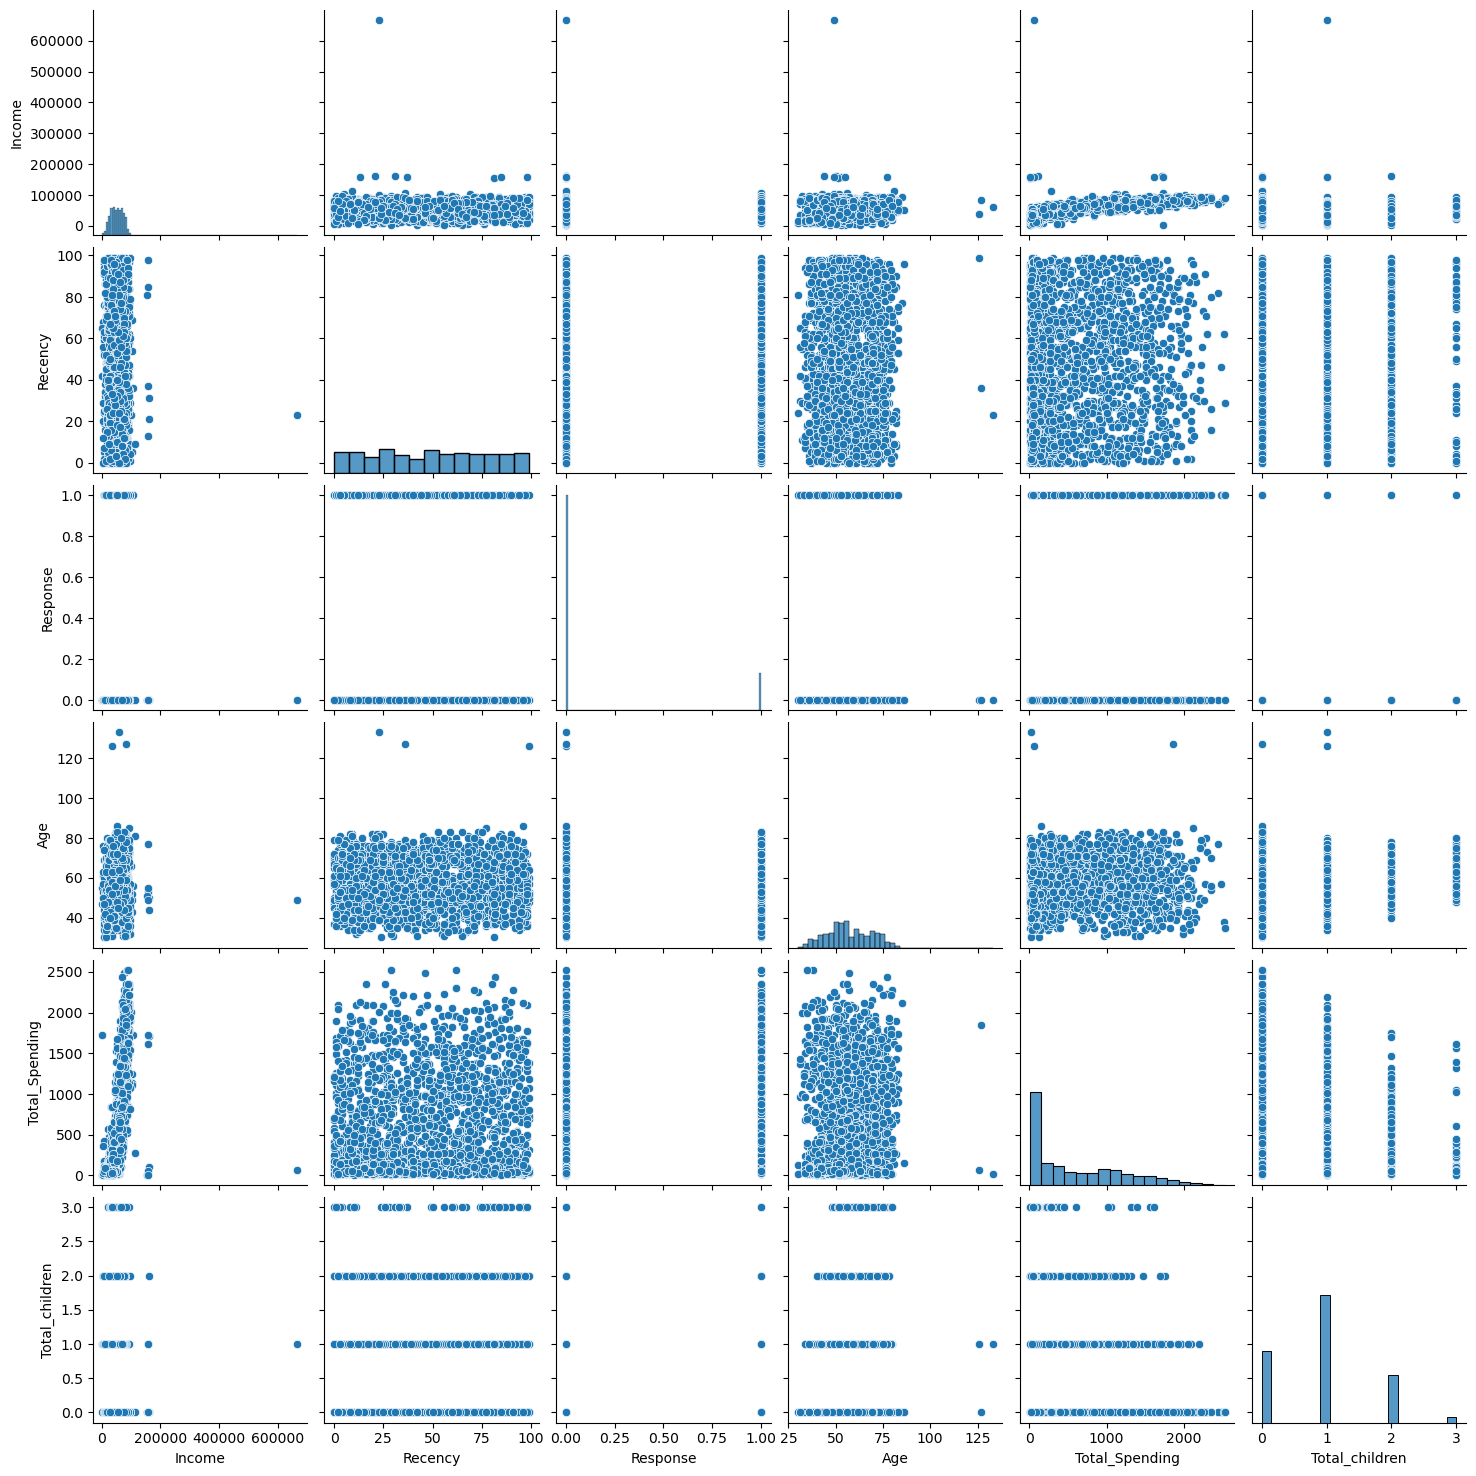

In [19]:
#outliers
cols=["Income","Recency","Response","Age","Total_Spending","Total_children"]

#relative plots of some features-pair plots
sns.pairplot(df_cleaned[cols])

In [20]:
#remove outliers
print("data size with outliers",len(df_cleaned))
df_cleaned=df_cleaned [(df_cleaned["Age"]<90)]
df_cleaned=df_cleaned [(df_cleaned["Income"]<600_000)]
print("data size without outliers",len(df_cleaned))

data size with outliers 2240
data size without outliers 2236


In [21]:
#heatmap
corr=df_cleaned.corr(numeric_only=True)

<Axes: >

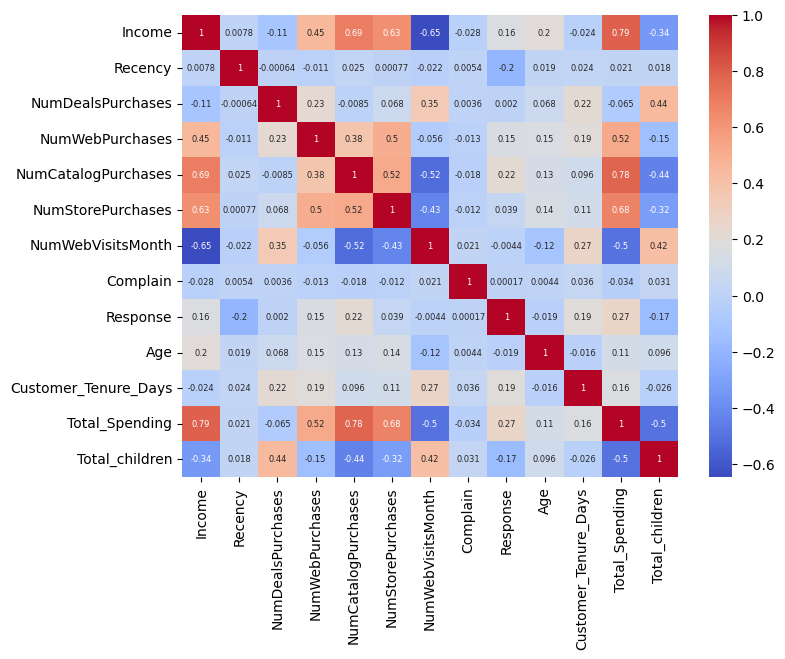

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,annot=True,
    annot_kws={"size":6},cmap="coolwarm"
)

In [23]:
#feature encoding
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()
cat_cols=["Education","Living_With"]
enc_cols=ohe.fit_transform(df_cleaned[cat_cols])

In [24]:
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [25]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [26]:
df_encoded.shape

(2236, 19)

In [27]:
df_encoded.head()
X=df_encoded

In [28]:
#scaling
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_scaled=scaler.fit_transform(X)

In [29]:
#visualise
X_scaled.shape

(2236, 19)

In [30]:
#2d visualise
from sklearn.decomposition import PCA
pca=PCA(
    n_components=3
)
X_pca=pca.fit_transform(X_scaled)
pca.explained_variance_ratio_

array([0.21952775, 0.10776148, 0.09860014])

Text(0.5, 0.92, '3d projection')

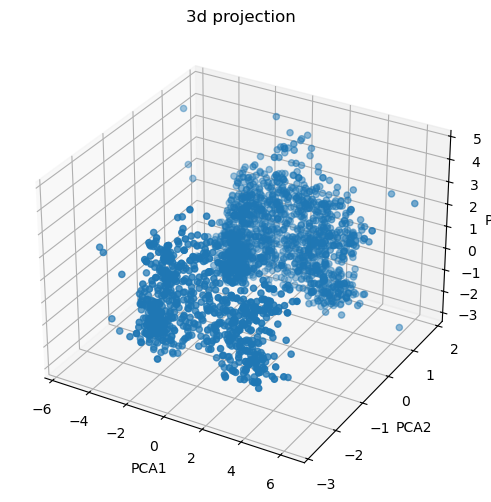

In [31]:
#plot
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

In [32]:
pca.explained_variance_ratio_

array([0.21952775, 0.10776148, 0.09860014])

In [33]:
#analyze k value
#1.elbow method
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)
    

In [34]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k=knee.elbow

In [35]:
print("best k=",optimal_k)


best k= 4


Text(0, 0.5, 'WCSS')

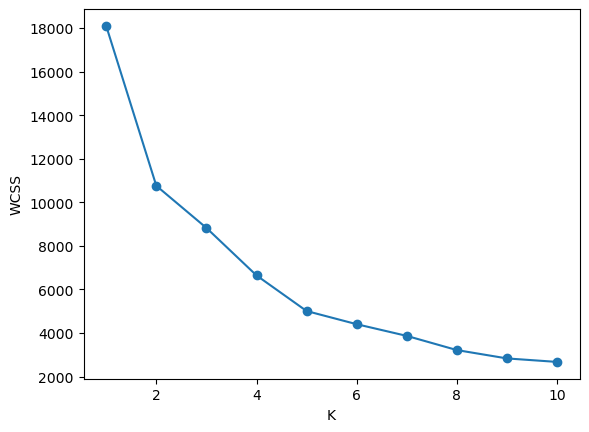

In [36]:
#plot 
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

Text(0, 0.5, 'silhouette_scores')

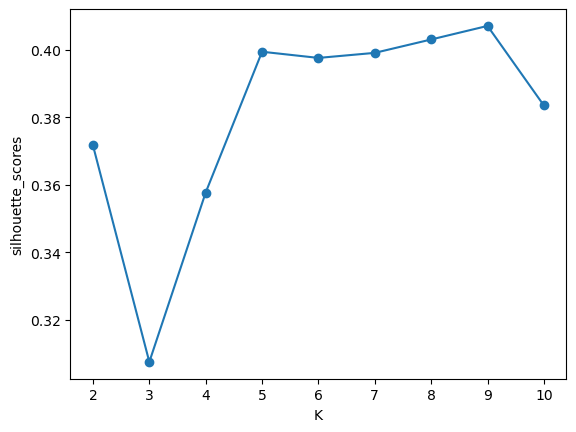

In [37]:
#2. silhouette score
from sklearn.metrics import silhouette_score
scores=[]
for k in range(2,11):
    
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(X_pca)
    score=silhouette_score(X_pca,labels)
    scores.append(score)

#plot
plt.plot(range(2,11),scores,marker='o')
plt.xlabel("K")
plt.ylabel("silhouette_scores")

Text(0.5, 0, 'SS')

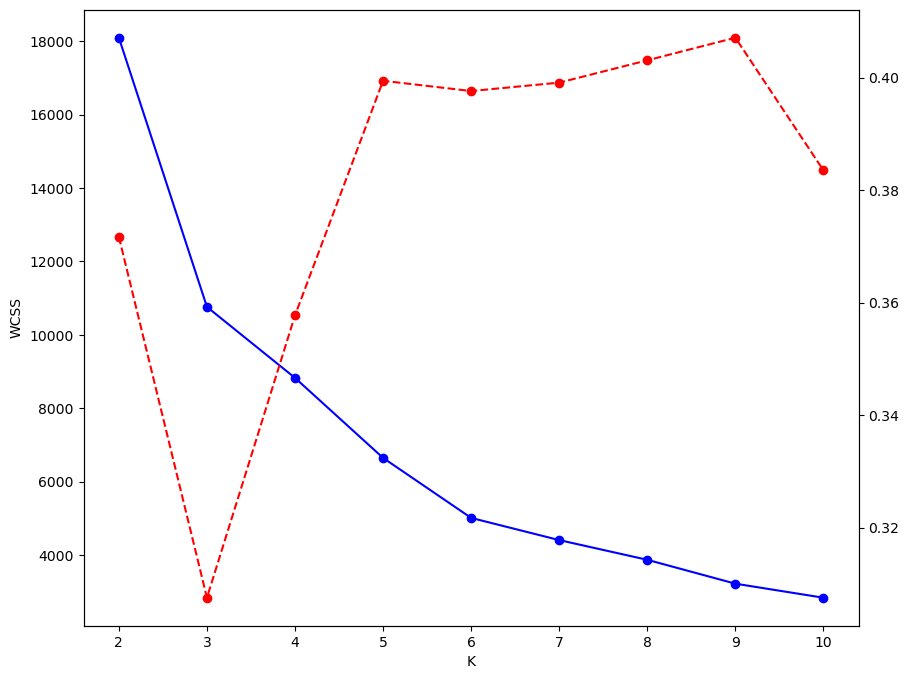

In [38]:
#combined plot
k_range=range(2,11)
fig,ax1=plt.subplots(figsize=(10,8))
ax1.plot(k_range,wcss[:len(k_range)],marker='o',color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker='o',color="red",linestyle="--")
ax2.set_xlabel("SS")

In [39]:
#clustering
#kmeans
kmeans=KMeans(n_clusters=4,random_state=42)
labels_kmeans=kmeans.fit_predict(X_pca)


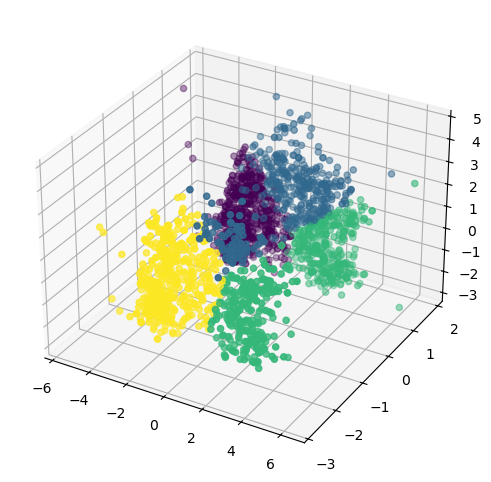

In [40]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c = labels_kmeans)

In [41]:
#agglomerative clustering
from sklearn.cluster import AgglomerativeClustering

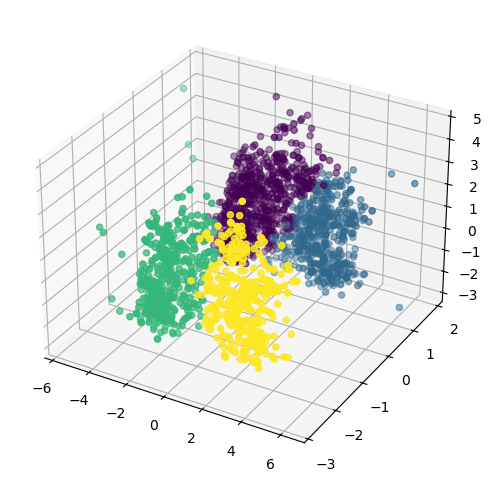

In [42]:
agg_clf=AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg=agg_clf.fit_predict(X_pca)
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)

In [54]:
#charcterisation of clusters
X["clusters"]=labels_agg

<Axes: xlabel='clusters', ylabel='count'>

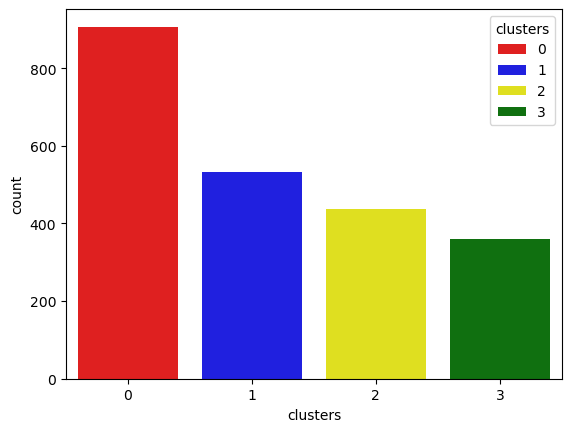

In [56]:
pal=["red","blue","yellow","green"]
sns.countplot(x=X["clusters"],palette=pal,hue=X["clusters"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

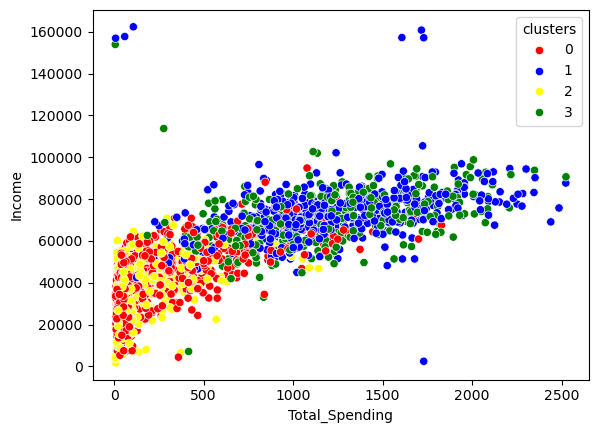

In [57]:
#income n spending pattern
#| Parameter     | Meaning                                      
#hue Decides what to color (e.g., cluster labels). 
#palette which colors to use.                  

sns.scatterplot(x=X["Total_Spending"],y=X["Income"],hue=X["clusters"],palette=pal)

In [61]:
#cluster summary
clusters_summary=X.groupby("clusters").mean()
print(clusters_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39940.962514  49.289967           2.714443         3.267916   
1         72489.063910  48.563910           1.751880         5.501880   
2         36658.799771  48.221968           2.574371         2.684211   
3         70431.984722  50.580556           1.894444         5.766667   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    1.065050           4.269019           6.433297  0.009923   
1                    5.351504           8.462406           3.355263  0.007519   
2                    0.803204           3.581236           6.693364  0.011442   
3                    4.975000           8.388889           3.744444  0.005556   

          Response        Age  Customer_Tenure_Days  Total_Spending  \
clu